
# Molecular Dynamics Simulation


DFTpy performs molecular dynamics (MD) simulations with `ASE`_.
This is one example to run NVT (canonical ensemble) simulation:


The output `md.traj` can be converted with `ASE`_:



.. _ASE: https://gitlab.com/ase/ase

Run this cell to install DFTpy in google colab

```bash
!python -m pip install "git+https://github.com/Quantum-MultiScale/DFTpy.git@dev"
```

Download the pseudopotential file

```bash
!wget https://raw.githubusercontent.com/Quantum-MultiScale/DFTpy/dev/DATA/Al_lda.oe01.recpot
```


In [1]:
import os
import pathlib
import numpy as np
from ase.lattice.cubic import FaceCenteredCubic
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.io.trajectory import Trajectory
from ase import units
from ase.md.npt import NPT

from dftpy.config import DefaultOption, OptionFormat
from dftpy.interface import OptimizeDensityConf
from dftpy.api.api4ase import DFTpyCalculator


For parallel implementation when running in python

In [2]:
# MPI / parallel setup 
from dftpy.mpi import MP, sprint
mp = MP(parallel=False) # Set parallel=True to run in parallel

Define initial configuration with DFTpy

In [3]:
conf = DefaultOption()
conf['PATH']['pppath'] = '../DATA'
conf['PP']['Al'] = 'Al_lda.oe01.recpot'
conf['OPT']['method'] = 'TN'
conf['KEDF']['kedf'] = 'WT'
conf['JOB']['calctype'] = 'Energy Force'
conf = OptionFormat(conf)

Build the system with ASE

In [4]:
size = 3
a = 4.24068463425528
T = 1023  # Kelvin
T *= units.kB
atoms = FaceCenteredCubic(directions=[[1, 0, 0], [0, 1, 0], [0, 0, 1]],
                          latticeconstant = a,
                          symbol="Al",
                          size=(size, size, size),
                          pbc=True)

Set the DFTpy calculator to the ase atoms

In [5]:
calc = DFTpyCalculator(config = conf) # DFTpy can be run in parallel using the MPI interface, as follows: DFTpyCalculator(config = conf, mp=mp) 
atoms.calc = calc

Perform the dynamics 

In [ ]:
MaxwellBoltzmannDistribution(atoms, T, force_temp = True)

dyn = Langevin(atoms, 2 * units.fs, T, 0.1)

step = 0
interval = 1
def printenergy(a=atoms):  
    global step, interval
    epot = a.get_potential_energy() / len(a)
    ekin = a.get_kinetic_energy() / len(a)
    print('Step={:<8d} Epot={:.5f} Ekin={:.5f} T={:.3f} Etot={:.5f}'.format(step, epot, ekin, ekin / (1.5 * units.kB), epot + ekin))
    step += interval
    
dyn.attach(printenergy, interval=1)

traj = Trajectory('md.traj', 'w', atoms)
dyn.attach(traj.write, interval=5)

dyn.run(500)


Analyse the trajectory by plotting the rdial distribution function (RDF)

In [25]:
from ase.geometry.analysis import Analysis
analysis = Analysis(list(Trajectory('md.traj')))
rdf = analysis.get_rdf(rmax=6, nbins=50, return_dists=True)
rdf = np.asarray(rdf).mean(axis=0)

In [20]:
import matplotlib.pyplot as plt

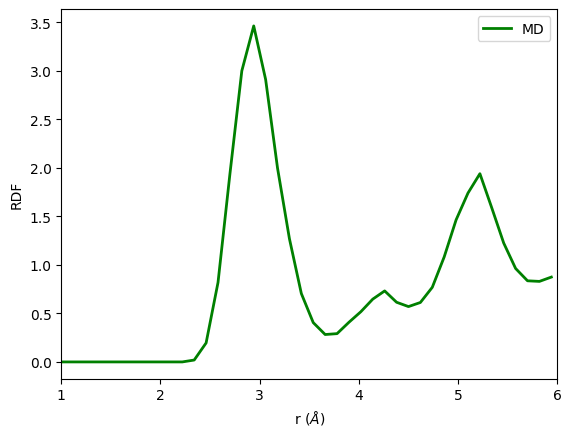

In [28]:
plt.plot(rdf[1], rdf[0], 'g', lw=2,label='MD')
plt.ylabel('RDF')
plt.xlabel(r'r ($\AA$)')
plt.xlim(1,6)
plt.legend()